## Ridge, LASSO, ElasticNet – Boston Housing

## 1. Dataset Overview



Shape: (506, 14)


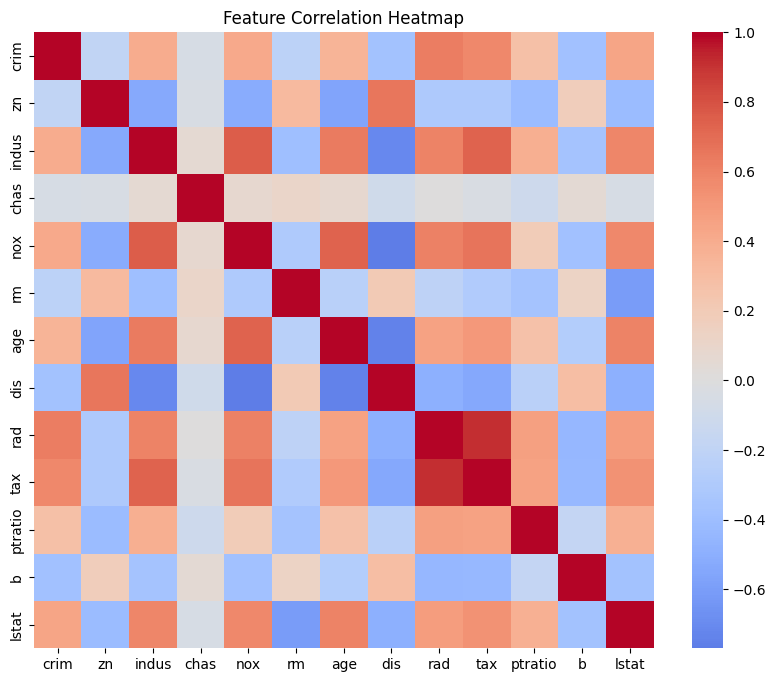

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('HousingData.csv')
df.columns = df.columns.str.lower()

print("Shape:", df.shape)

X = df.drop(columns=['medv'])
y = df['medv']

plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

## 2. Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")), # it fills missing values, otherwise models crash
    ("scaler", StandardScaler()) # it makes all features comparable
])

X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

## 3. Regularization Sweep

In [5]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet

alphas = np.logspace(-4, 2, 80)

ridge_coefs, lasso_coefs, enet_coefs = [], [], []

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train, y_train)
    lasso = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    enet = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=10000).fit(X_train, y_train)

    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)
    enet_coefs.append(enet.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)
enet_coefs = np.array(enet_coefs)

## 4. Coefficient Paths Comparison

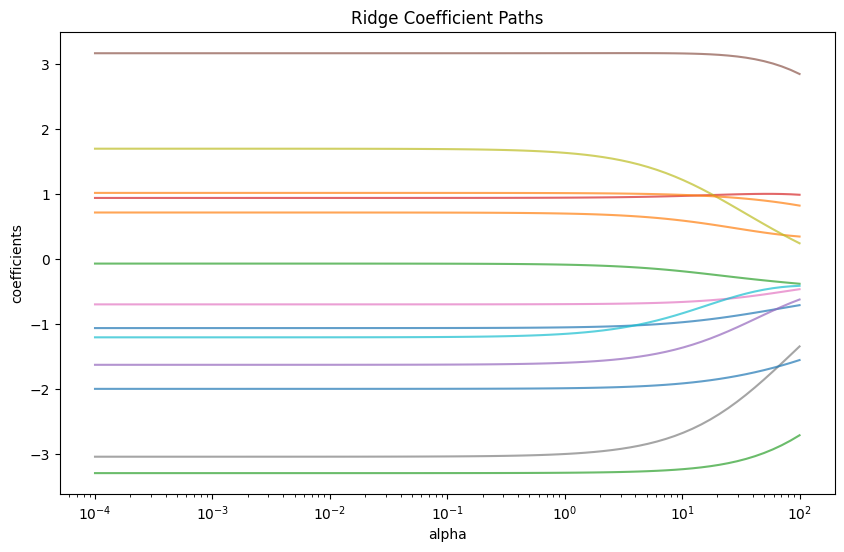

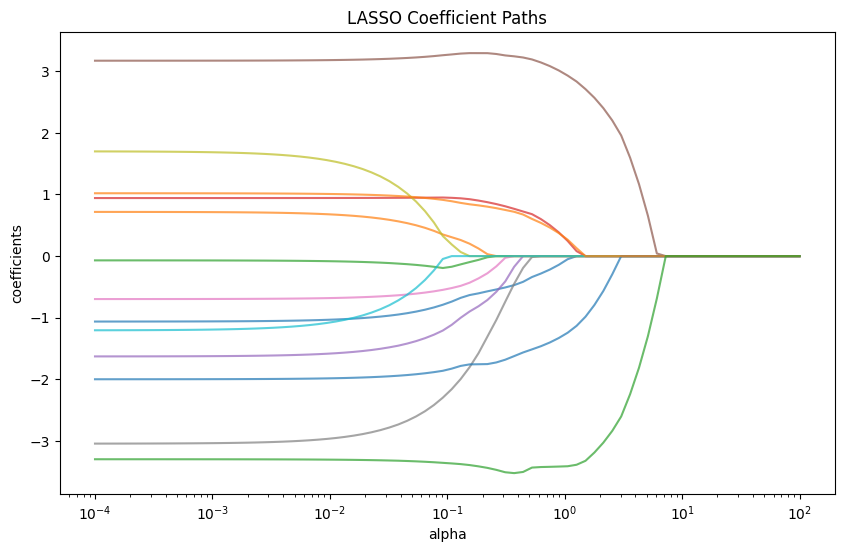

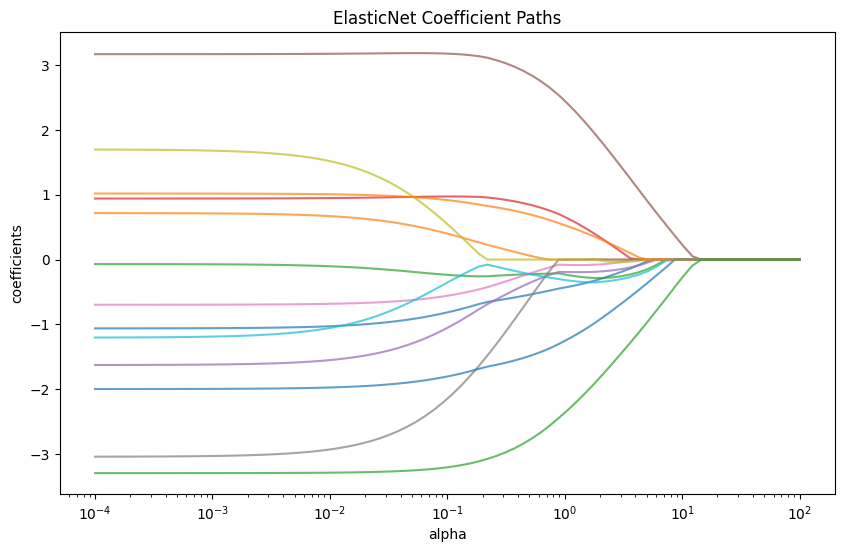

In [6]:
features = X.columns

plt.figure(figsize=(10,6))
for i in range(len(features)):
    plt.plot(alphas, ridge_coefs[:, i], alpha=0.7)
plt.xscale('log')
plt.title("Ridge Coefficient Paths")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.show()

plt.figure(figsize=(10,6))
for i in range(len(features)):
    plt.plot(alphas, lasso_coefs[:, i], alpha=0.7)
plt.xscale('log')
plt.title("LASSO Coefficient Paths")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.show()

plt.figure(figsize=(10,6))
for i in range(len(features)):
    plt.plot(alphas, enet_coefs[:, i], alpha=0.7)
plt.xscale('log')
plt.title("ElasticNet Coefficient Paths")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.show()

## 5. Active Features Comparison

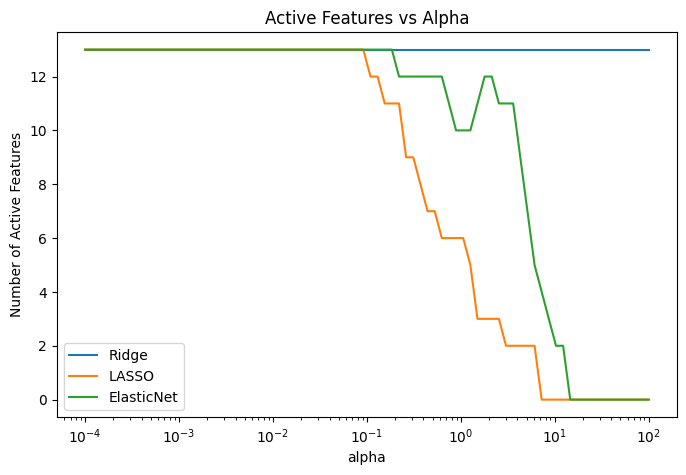

In [7]:
ridge_active = np.sum(ridge_coefs != 0, axis=1)
lasso_active = np.sum(lasso_coefs != 0, axis=1)
enet_active = np.sum(enet_coefs != 0, axis=1)

plt.figure(figsize=(8,5))
plt.plot(alphas, ridge_active, label="Ridge")
plt.plot(alphas, lasso_active, label="LASSO")
plt.plot(alphas, enet_active, label="ElasticNet")
plt.xscale('log')
plt.legend()
plt.title("Active Features vs Alpha")
plt.xlabel("alpha")
plt.ylabel("Number of Active Features")
plt.show()

## 6. Performance Comparison

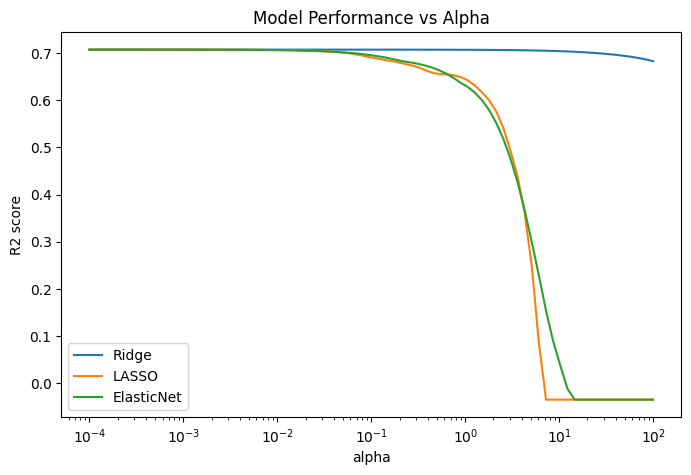

In [10]:
from sklearn.metrics import r2_score

ridge_scores, lasso_scores, enet_scores = [], [], []

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train, y_train)
    lasso = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    enet = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=10000).fit(X_train, y_train)

    ridge_scores.append(r2_score(y_test, ridge.predict(X_test)))
    lasso_scores.append(r2_score(y_test, lasso.predict(X_test)))
    enet_scores.append(r2_score(y_test, enet.predict(X_test)))

plt.figure(figsize=(8,5))
plt.plot(alphas, ridge_scores, label="Ridge")
plt.plot(alphas, lasso_scores, label="LASSO")
plt.plot(alphas, enet_scores, label="ElasticNet")
plt.xscale('log')
plt.legend()
plt.title("Model Performance vs Alpha")
plt.xlabel("alpha")
plt.ylabel("R2 score")
plt.show()

## 7. Feature Elimination Order

In [9]:
feature_names = X.columns
zero_points = {}

for i, name in enumerate(feature_names):
    coef_path = lasso_coefs[:, i]
    zero_idx = np.where(coef_path == 0)[0]

    zero_points[name] = alphas[zero_idx[0]] if len(zero_idx) > 0 else None

sorted_features = sorted(zero_points.items(), key=lambda x: (x[1] is None, x[1]))

pd.DataFrame(sorted_features, columns=["Feature", "Alpha where removed"])

,Feature,Alpha where removed
0,tax,0.109138
1,rad,0.154837
2,zn,0.261650
3,indus,0.261650
4,age,0.371211
5,nox,0.442150
6,dis,0.627290
7,crim,1.262600
8,chas,1.503887
9,b,1.503887
